# **Analysis multi run: P001S001 R02 to R05 - Inf -> Holding**

A generalized version of the single-run analysis. Each run is preprocessed independently (bad channel detection, filtering, average referencing, ICA), and the epochs from the four runs are then concatenated into a single `Epochs` object to run the cluster-based permutation test on the complete dataset.

The reason for separate preprocessing is that bad channels differ across runs (e.g., Fp2 in R04, and T8 in R03 and R05), and the average reference would be contaminated if calculated based on the raw concatenation.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from BCI2kReader import BCI2kReader as b2k
from autoreject import AutoReject
from mne.channels import find_ch_adjacency
from mne.stats import combine_adjacency, permutation_cluster_test
import warnings

warnings.filterwarnings("ignore")
mne.set_log_level("WARNING")

# **Settings**

In [2]:
# Root where all the ".dat" files are
ROOT = "/Users/alberto/Desktop/dat/Files"
# Name of all the P001 runs
RUNS = [
    "P001S001R02",
    "P001S001R03",
    "P001S001R04",
    "P001S001R05",
]

# PressureTarget in mmHg -> condition label
TARGET_MAP = {8: "none", 46: "low", 111: "high"}

# Stimulus Phase + 1, so HOLDING (phase 2) stays as event 3
EVENT_ID = {"hold": 3}

# Time that is going to be studied in ERP -0.5 to 9.5 seconds.
# The shortest holding window across the 120 trials is 10.00 s, so the
# epoch always fits inside the phase and never reaches the rating screen.
TMIN = -0.5
TMAX = 9.5
BASELINE = (-0.2, 0.0)

# Low and High Frequency Filters
L_FREQ = 0.1
H_FREQ = 40.0

"""¿Puedo bajar de 256 Hz a una frecuencia menor para hacer los cálculos más rápidos?"""
# The permutation test on 32 channels x 2561 samples is unnecessarily expensive.
# With DECIM = 3, the Nyquist frequency is 42.7 Hz, above the 40 Hz low-pass cutoff,
# so there is no aliasing. With DECIM = 4 the Nyquist would drop to 32 Hz and MNE warns.
DECIM = 3

# Z-score threshold used to identify bad or abnormal channels.
# Raised from 3.5 to 5.0. With 32 channels the MAD is small and 3.5 flags
# normal channels as bad.
Z_THRESH_BAD = 5.0
# Channels excluded from the variance criterion, their variance is ocular
EOG_LIKE = ("Fp1", "Fp2")
# Number of permutations used in permutation-based statistical tests
N_PERMUTATIONS = 1000
# Random seed to make the analysis reproducible
SEED = 97

# Region of interest. The fixation notebook reads the response on an occipital ROI
# because the anchor is visual. The anchor here is a somatosensory stimulus on the arm,
# so the equivalent region is the vertex.
CENTRAL_ROI = ["Cz", "C3", "C4", "CPz", "CP1", "CP2", "FC1", "FC2"]

# **Auxiliary functions**

## **Unit conversion**

`mne.io.read_raw_bci2k` reads the samples as stored and does not apply `SourceChGain`
or `SourceChOffset`. The conversion is therefore only valid when the gain is 1, which
is the case in these recordings. `check_units` asserts it instead of assuming it.

In [3]:
def to_volts(x):
    """BCI2k delivers microvolts and MNE expects volts"""
    return x * 1e-6

# Sanity check
def check_units(path):
    """Read SourceChGain and SourceChOffset from the header and confirm the 1e-6 scaling."""
    with b2k.BCI2kReader(path) as reader:
        gains = [float(g) for g in reader.parameters["SourceChGain"]]
        offsets = [float(o) for o in reader.parameters["SourceChOffset"]]

    ok = all(g == 1.0 for g in gains) and all(o == 0.0 for o in offsets)

    if not ok:
        raise ValueError(
            "SourceChGain is not 1 or SourceChOffset is not 0 in this file. "
            "read_raw_bci2k does not apply them, so to_volts would give wrong "
            "amplitudes. Gains: " + str(sorted(set(gains)))
        )

    return True

## **Automatic detection of bad channels**

The detection runs on **band-pass filtered** data. The amplifier is DC coupled, so before filtering the standard deviation of every channel sits in the tens of thousands of microvolts and is dominated by drift. Ranking channels by that number does not say anything about data quality.

Fp1 and Fp2 are removed from the variance criterion because their variance comes from blinks. For those two channels only a flat or saturated test is applied, which is what actually identifies a disconnected electrode.

**The criterion applied:** *robust z-score based on the standard deviation of each channel using MAD, and flat-channel test.*

In [4]:
def detect_bad_channels(raw, z_thresh=Z_THRESH_BAD):
    # Channels judged by variance, frontal poles excluded
    picks = []
    for name in raw.ch_names:
        if name not in EOG_LIKE:
            picks.append(name)

    data = raw.copy().pick(picks).get_data()

    # Calculate the signal variability for each channel
    std_per_channel = np.std(data, axis=1)

     # Use the median and MAD (Median Absolute Deviation) for robust outlier detection
    median_std = np.median(std_per_channel)
    mad = np.median(np.abs(std_per_channel - median_std))

    bads = []

    # Calculate the robust (modified) z-score for each channel
    if mad > 0:
        robust_z = 0.6745 * (std_per_channel - median_std) / mad

        for i in range(len(picks)):
            is_outlier = abs(robust_z[i]) > z_thresh
            is_flat = std_per_channel[i] < 0.05 * median_std

            if is_outlier or is_flat:
                bads.append(picks[i])

    # Frontal poles, flat or saturated only
    all_data = raw.get_data()
    all_std = np.std(all_data, axis=1)
    all_median = np.median(all_std)

    for name in EOG_LIKE:
        if name in raw.ch_names:
            i = raw.ch_names.index(name)
            if all_std[i] < 0.05 * all_median or all_std[i] > 50 * all_median:
                bads.append(name)

    return bads

A channel is considered **bad** if it has either:

- **Abnormal variability:** its robust z-score satisfies \(|z| > 3.5\).
- **A nearly flat signal:** its standard deviation is less than 5% of the median standard deviation across channels.

These criteria identify channels with unusually noisy or unusually low-variability signals.

## **Loading a run**

Reads the `.dat` file, adds the stimulus channel derived from `StimulusPhase`, extracts the events, and also returns the raw states needed later to label the condition of each trial.

In [5]:
def load_run(run_name):
    path = f"{ROOT}/{run_name}.dat"

    check_units(path)

    raw = mne.io.read_raw_bci2k(path, preload=True)

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        trial_state = reader.states["TrialNumber"].ravel()
        target_state = reader.states["PressureTarget"].ravel()
        ch_names = list(reader.parameters["ChannelNames"])

    # Drop the stim channel that read_raw_bci2k adds from StimulusCode, it is unused here
    eeg_only = []
    for name in raw.ch_names:
        if name.startswith("EEG"):
            eeg_only.append(name)
    raw.pick(eeg_only)

    rename = {}
    for i in range(len(eeg_only)):
        rename[eeg_only[i]] = ch_names[i]

    raw.rename_channels(rename)
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"))

    # Convert once, at load time, so everything downstream is in volts
    raw.apply_function(to_volts, picks="eeg")

    return raw, phase_state, trial_state, target_state

# **Holding events and trial labelling**

The rising edge into `StimulusPhase == 0` marks the fixation onset.

The trial id is read at the **end** of the fixation window and not at its onset. On the first trial
of every run the controller writes `TrialNumber` roughly one and a half seconds after the fixation
has already started, so reading it at the onset returned 0 and the trial was thrown away together
with the calibration cycle. The true calibration cycle never produces a rising edge because the
recording already starts inside phase 0, so it is excluded automatically.

In [6]:
def hold_events(phase_state, trial_state, target_state):
    onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 2 and phase_state[ii - 1] != 2:
            onsets.append(ii)

    events = []
    trials = []
    conditions = []

    for start in onsets:
        trial_num = int(trial_state[start])

        # Calibration cycle
        if trial_num == 0:
            continue

        # PressureTarget does not change inside the holding window,
        # so the value at onset already identifies the condition
        target = int(target_state[start])
        if target not in TARGET_MAP:
            continue

        events.append([start, 0, EVENT_ID["hold"]])
        trials.append(trial_num)
        conditions.append(TARGET_MAP[target])

    return np.array(events, dtype=int), trials, conditions

## **Preprocessing**

Order matters here. Filter first, then detect bad channels on the filtered signal, then interpolate,
then average reference. Interpolating before referencing is what keeps a single disconnected
electrode from contaminating all 32 channels, which is what happened with Fp2 in R04.

`reset_bads=True` is kept so the four runs end with identical `info` and can be concatenated.

In [7]:
def preprocess(raw):
    # Band-pass first
    raw.filter(l_freq = L_FREQ, h_freq = H_FREQ, picks = "eeg")

    # Detect on the filtered signal
    bads = detect_bad_channels(raw)
    raw.info["bads"] = bads

    # Interpolate bad channels
    if len(bads) > 0:
        raw.interpolate_bads(reset_bads = True)

    raw.set_eeg_reference("average", projection = True)

    return bads

## **ICA for blinks**

In the single-run version, the component to exclude was fixed at `[0]`. This is not
safe for generalization because the component order changes between runs. Here, the
output of `find_bads_eog` is used directly.

The EOG proxy channel is also selected conditionally: if Fp1 was detected as
bad, Fp2 is used, and vice versa.

In [8]:
def run_ica(raw, bads):
    # ICA works better with a 1 Hz high-pass filter
    raw_ica = raw.copy().filter(l_freq=1.0, h_freq=None, picks="eeg")

    # ICA
    ica = mne.preprocessing.ICA(
        n_components=20,
        random_state=SEED,
        max_iter="auto",
    )
    ica.fit(raw_ica, picks="eeg")

    # Select a frontal channel as an EOG proxy (Fp1 or Fp2)
    eog_proxy = "Fp1"
    for candidate in ["Fp1", "Fp2"]:
        if candidate not in bads:
            eog_proxy = candidate
            break

    # Find bad EOG
    eog_indices, eog_scores = ica.find_bads_eog(
        raw_ica,
        ch_name=eog_proxy,
        threshold=2.5
    )
    ica.exclude = eog_indices

    # Apply ICA
    raw_clean = raw.copy()
    if len(eog_indices) > 0:
        ica.apply(raw_clean)

    return raw_clean, eog_indices, eog_proxy

# **EPOCHING**

`proj=True` applies the average reference projection at epoch creation. The condition labels
come straight from `hold_events`, so no second pass over the states is needed.

In [9]:
def build_epochs(raw_clean, events, trials, conditions, run_name):
    epochs = mne.Epochs(
        raw_clean,
        events,
        event_id = EVENT_ID,
        tmin = TMIN,
        tmax = TMAX,
        baseline = BASELINE,
        preload = True,
        decim = DECIM,
        proj = True,
    )

    epochs.metadata = pd.DataFrame({
        "run": [run_name] * len(trials),
        "trial": trials,
        "condition": conditions,
    })

    return epochs

# **Marker timing check**

BCI2000 updates the state vector once per sample block, and `SampleBlockSize = 32` at 256 Hz
means one block is 125 ms. If every holding onset falls on a multiple of 32 samples, the marker
does not carry sub-block timing.

For a tonic 10 second stimulus this matters far less than it does for a visual P1, because the
effect being measured lasts seconds and not tens of milliseconds. It is still worth reporting.

In [10]:
timing_rows = []

# Sanity check
for run_name in RUNS:
    path = f"{ROOT}/{run_name}.dat"

    with b2k.BCI2kReader(path) as reader:
        phase_state = reader.states["StimulusPhase"].ravel()
        block_size = int(reader.parameters["SampleBlockSize"])
        sfreq = float(reader.parameters["SamplingRate"])

    onsets = []
    for ii in range(1, len(phase_state)):
        if phase_state[ii] == 2 and phase_state[ii - 1] != 2:
            onsets.append(ii)

    remainders = sorted(set([o % block_size for o in onsets]))

    timing_rows.append({
        "run": run_name,
        "block_size": block_size,
        "block_ms": 1000.0 * block_size / sfreq,
        "n_hold_onsets": len(onsets),
        "onset_remainders_mod_block": str(remainders),
    })

timing_df = pd.DataFrame(timing_rows)
timing_df

,run,block_size,block_ms,n_hold_onsets,onset_remainders_mod_block
0,P001S001R02,32,125.0,31,[0]
1,P001S001R03,32,125.0,31,[0]
2,P001S001R04,32,125.0,31,[0]
3,P001S001R05,32,125.0,31,[0]


# **Processing the 4 runs**

In [11]:
epochs_by_run = []
diagnostics = []

for run_name in RUNS:
    print(f"Procesando {run_name} ...")

    raw, phase_state, trial_state, target_state = load_run(run_name)
    events, trials, conditions = hold_events(phase_state, trial_state, target_state)

    bads = preprocess(raw)
    raw_clean, eog_indices, eog_proxy = run_ica(raw, bads)

    epochs = build_epochs(raw_clean, events, trials, conditions, run_name)

    counts = epochs.metadata["condition"].value_counts()
    diagnostics.append({
        "run": run_name,
        "n_hold_events": len(events),
        "bad_channels": ", ".join(bads) if bads else "-",
        "eog_proxy": eog_proxy,
        "ica_excluded": ", ".join(str(i) for i in eog_indices) if len(eog_indices) else "-",
        "n_epochs": len(epochs),
        "none": int(counts.get("none", 0)),
        "low": int(counts.get("low", 0)),
        "high": int(counts.get("high", 0)),
    })

    epochs_by_run.append(epochs)

    del raw, raw_clean

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

Procesando P001S001R02 ...


Procesando P001S001R03 ...


Procesando P001S001R04 ...


Procesando P001S001R05 ...


,run,n_hold_events,bad_channels,eog_proxy,ica_excluded,n_epochs,none,low,high
0,P001S001R02,30,-,Fp1,0,30,10,10,10
1,P001S001R03,30,"T8, P4",Fp1,0,30,10,10,10
2,P001S001R04,30,"F4, Fp2",Fp1,0,30,10,10,10
3,P001S001R05,30,"FC6, P4, O1",Fp1,0,30,10,10,10


# **Concatenate the runs**

In [12]:
epochs_all = mne.concatenate_epochs(epochs_by_run)

print(epochs_all)
print("shape:", epochs_all.get_data().shape)
print("sfreq:", epochs_all.info["sfreq"], "Hz")
print("window:", epochs_all.times[0], "to", epochs_all.times[-1], "s")
print()
print(epochs_all.metadata["condition"].value_counts())

<EpochsArray | 120 events (all good), -0.492 – 9.492 s (baseline -0.2 – 0 s), ~25.0 MiB, data loaded, with metadata,
 'hold': 120>
shape: (120, 32, 853)
sfreq: 85.33333333333333 Hz
window: -0.4921875 to 9.4921875 s

condition
high    40
none    40
low     40
Name: count, dtype: int64


# **AutoReject on the combined set**

It is run once across the 120 epochs instead of four times across 30. With more epochs,
AutoReject's internal cross-validation estimates much more stable
channel-specific thresholds.

If you prefer to treat each run separately (for example, if you suspect one had a
significantly different noise level), simply move this cell inside the previous loop.

In [13]:
ar = AutoReject(
    random_state = SEED,
    n_jobs = 1,
    verbose = False,
)

epochs_clean, reject_log = ar.fit_transform(epochs_all, return_log = True)

print(f"Kept {len(epochs_clean)} / {len(epochs_all)} epochs")
print()
print(epochs_clean.metadata.groupby(["run", "condition"]).size().unstack(fill_value = 0))

Kept 120 / 120 epochs

condition    high  low  none
run                         
P001S001R02    10   10    10
P001S001R03    10   10    10
P001S001R04    10   10    10
P001S001R05    10   10    10


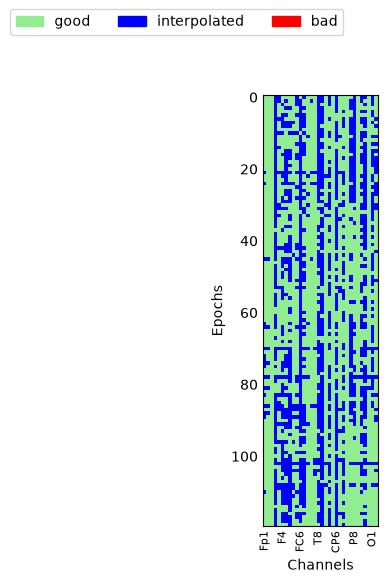

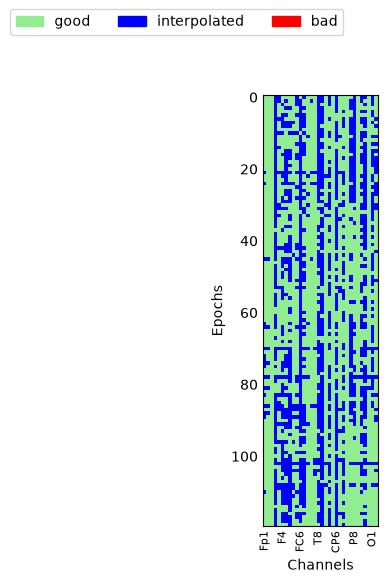

In [14]:
reject_log.plot()

## **Checking balance after rejection**

If AutoReject removes epochs unevenly across conditions, the permutation test remains valid but loses power in the most affected group.

In [15]:
balance = epochs_clean.metadata["condition"].value_counts()
print(balance)

if balance.max() - balance.min() > 0.2 * balance.max():
    print()
    print("WARNING: imbalance greater than 20 percent between conditions")

condition
high    40
none    40
low     40
Name: count, dtype: int64


# **Separation between none, low and high**

This is the section that answers the question directly. Three views of the same thing:
the central ROI with confidence intervals, the GFP, and the single trials.

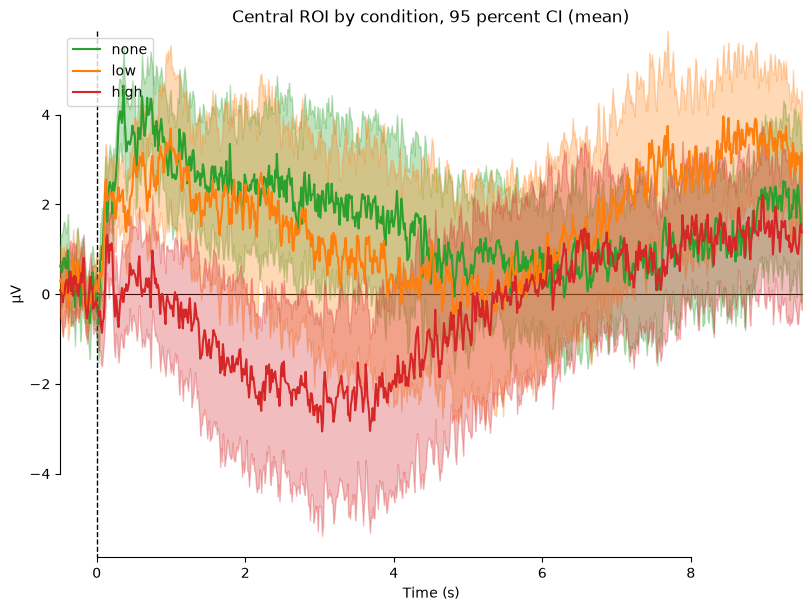

[<Figure size 800x600 with 1 Axes>]

In [16]:
central_roi = []
for name in CENTRAL_ROI:
    if name in epochs_clean.ch_names:
        central_roi.append(name)

by_condition = {}
for condition in ["none", "low", "high"]:
    by_condition[condition] = list(epochs_clean[f"condition == '{condition}'"].iter_evoked())

mne.viz.plot_compare_evokeds(
    by_condition,
    picks = central_roi,
    combine = "mean",
    colors = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"},
    title = "Central ROI by condition, 95 percent CI",
)

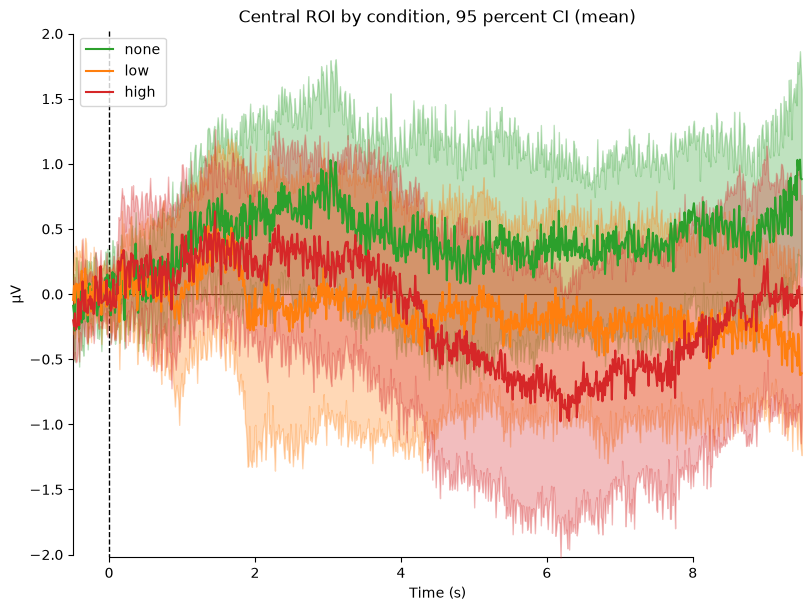

[<Figure size 800x600 with 1 Axes>]

In [17]:
central_roi = []
for name in CENTRAL_ROI:
    if name in epochs_clean.ch_names:
        central_roi.append(name)

by_condition = {}
for condition in ["none", "low", "high"]:
    by_condition[condition] = list(epochs_clean[f"condition == '{condition}'"].iter_evoked())

mne.viz.plot_compare_evokeds(
    by_condition,
    picks = "eeg",
    combine = "mean",
    colors = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"},
    title = "Central ROI by condition, 95 percent CI",
)

In [18]:
evokeds = {}

for condition in ["none", "low", "high"]:
    evokeds[condition] = epochs_clean[f"condition == '{condition}'"].average()
    print(evokeds[condition])

<Evoked | 'hold' (average, N=40), -0.49219 – 9.4922 s, baseline -0.2 – 0 s, 32 ch, ~256 KiB>
<Evoked | 'hold' (average, N=40), -0.49219 – 9.4922 s, baseline -0.2 – 0 s, 32 ch, ~256 KiB>
<Evoked | 'hold' (average, N=40), -0.49219 – 9.4922 s, baseline -0.2 – 0 s, 32 ch, ~256 KiB>


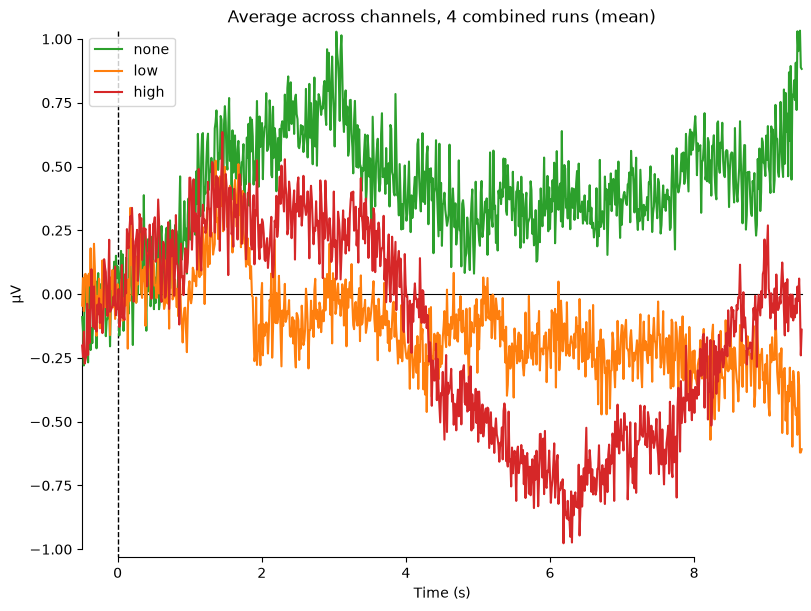

[<Figure size 800x600 with 1 Axes>]

In [19]:
mne.viz.plot_compare_evokeds(
    evokeds,
    picks = "eeg",
    combine = "mean",
    colors = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"},
    title = "Average across channels, 4 combined runs",
)

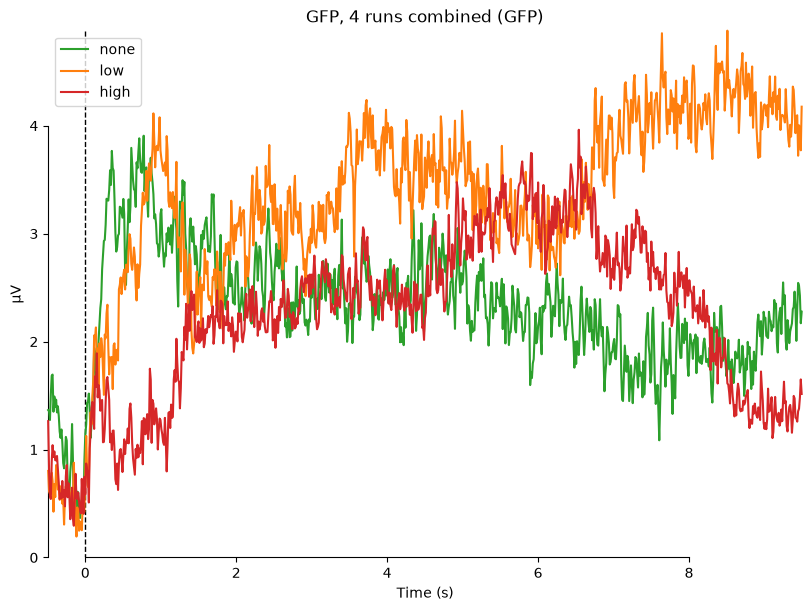

[<Figure size 800x600 with 1 Axes>]

In [20]:
# GFP
mne.viz.plot_compare_evokeds(
    evokeds,
    picks = "eeg",
    colors = {"none": "tab:green", "low": "tab:orange", "high": "tab:red"},
    title = "GFP, 4 runs combined",
)

## **Single trials per condition**

The image plot shows whether the condition average is carried by all trials or by a handful of large ones.

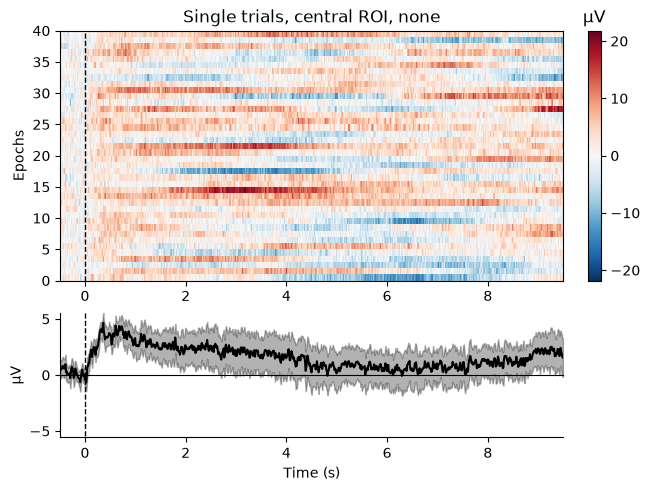

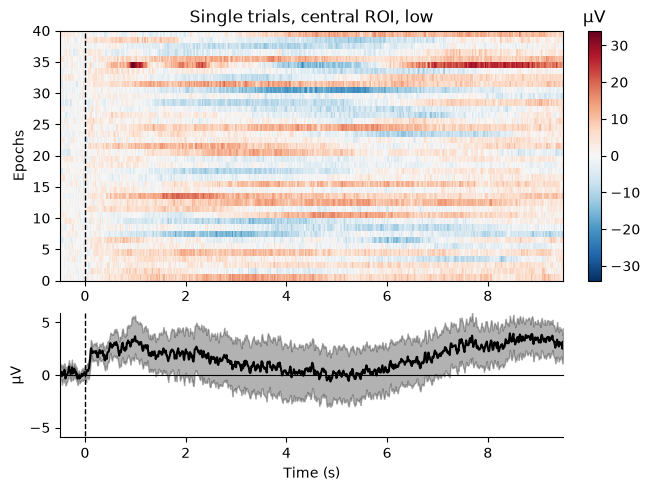

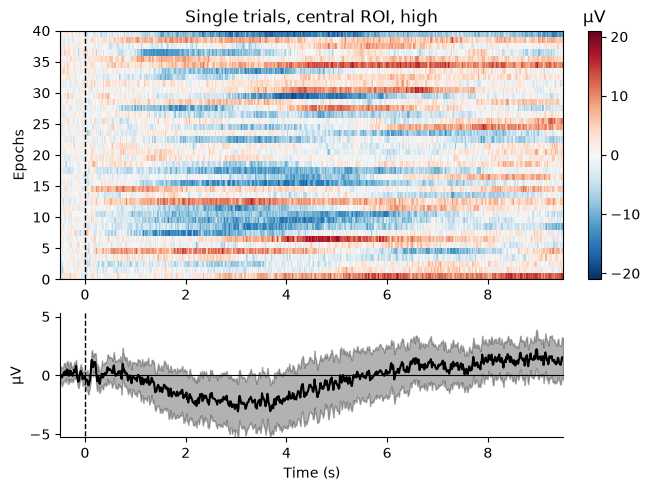

In [21]:
for condition in ["none", "low", "high"]:
    epochs_clean[f"condition == '{condition}'"].plot_image(
        picks = central_roi,
        combine = "mean",
        title = f"Single trials, central ROI, {condition}",
    )

## **Mean amplitude over the holding window**

A single number per condition, averaged over the central ROI and the whole 0 to 9.5 s window.

In [22]:
times = epochs_clean.times
window = (times >= 0.0) & (times <= 9.5)

rows = []
for condition in ["none", "low", "high"]:
    data = epochs_clean[f"condition == '{condition}'"].get_data(picks = central_roi)
    per_epoch = data[:, :, window].mean(axis = 1).mean(axis = 1) * 1e6
    rows.append({
        "condition": condition,
        "n": len(per_epoch),
        "mean_uV": per_epoch.mean(),
        "sd_uV": per_epoch.std(),
        "sem_uV": per_epoch.std() / np.sqrt(len(per_epoch)),
    })

pd.DataFrame(rows)

,condition,n,mean_uV,sd_uV,sem_uV
0,none,40,1.633276,3.009512,0.475846
1,low,40,1.701578,4.699572,0.743067
2,high,40,-0.316147,4.312042,0.681794


# **Cluster based permutation test**

## **Spatiotemporal adjacency**

In [23]:
# Compute spatial adjacency between neighboring EEG channels
adjacency, ch_names = find_ch_adjacency(epochs_clean.info, ch_type="eeg")

# Combine spatial and temporal adjacency for cluster-based statistics
n_times = len(epochs_clean.times)
adjacency_st = combine_adjacency(n_times, adjacency)

print("spatial adjacency:", adjacency.shape)
print("spatio-temporal adjacency:", adjacency_st.shape)
print("nodes:", n_times, "samples x", len(ch_names), "channels")

spatial adjacency: (32, 32)
spatio-temporal adjacency: (27296, 27296)
nodes: 853 samples x 32 channels


## **Preparing the matrices**

`permutation_cluster_test` expects `(epochs, time, channels)`, whereas
`get_data` returns `(epochs, channels, time)`.

In [24]:
X = {}

for condition in ["none", "low", "high"]:
    # Extract EEG data for each condition
    data = epochs_clean[f"condition == '{condition}'"].get_data(picks="eeg")
    # Rearrange to (epochs, time, channels) for the cluster test
    X[condition] = data.transpose(0, 2, 1)
    print(condition, X[condition].shape)

none (40, 853, 32)
low (40, 853, 32)
high (40, 853, 32)


## **Reporting function**

Runs the test and summarizes the clusters ordered by p-value, indicating the time window and the channels involved.

In [25]:
def run_cluster_test(label, groups, alpha=0.05):
    # Run a spatio-temporal permutation cluster test
    T_obs, clusters, p_values, H0 = permutation_cluster_test(
        groups,
        adjacency=adjacency_st,
        n_permutations=N_PERMUTATIONS,
        tail=1,
        threshold=None,
        out_type="mask",
        n_jobs=1,
        seed=SEED,
        verbose=False,
    )

    print("=" * 70)
    print(label)
    print("=" * 70)

    if len(p_values) == 0:
        print("No cluster was formed")
        return T_obs, clusters, p_values

    # Sort clusters from smallest to largest p-value
    order = np.argsort(p_values)
    n_sig = int((p_values < alpha).sum())
    print(f"clusters formados: {len(clusters)}   significativos (p < {alpha}): {n_sig}")
    print(f"p minimo: {p_values.min():.4f}")
    print()

    # Display the five most significant clusters
    for rank, k in enumerate(order[:5]):
        mask = clusters[k]
        time_idx, ch_idx = np.where(mask)
        involved = sorted(set(ch_names[c] for c in ch_idx))
        flag = "*" if p_values[k] < alpha else " "
        print(
            f"{flag} Cluster {rank + 1}: p = {p_values[k]:.4f}, "
            f"{int(mask.sum())} nodes, "
            f"t = [{epochs_clean.times[time_idx.min()]:.2f}, "
            f"{epochs_clean.times[time_idx.max()]:.2f}] s, "
            f"{len(involved)} channels"
        )
        print(f"    {', '.join(involved)}")
    print()

    return T_obs, clusters, p_values

## **Omnibus test for the three conditions**

Before making pairwise comparisons, it is advisable to conduct a single F-test across the three conditions. If this test is not significant, the pairwise comparisons should not be interpreted either.

In [26]:
# Run the omnibus test across all three experimental conditions
T_obs_omni, clusters_omni, p_omni = run_cluster_test(
    "OMNIBUS  none vs low vs high",
    [X["none"], X["low"], X["high"]],
)

OMNIBUS  none vs low vs high
clusters formados: 122   significativos (p < 0.05): 2
p minimo: 0.0020

* Cluster 1: p = 0.0020, 3416 nodes, t = [0.20, 4.07] s, 30 channels
    C3, C4, CP1, CP2, CP5, CP6, CPz, Cz, F3, F4, F8, FC1, FC2, FC5, FC6, Fp2, Fz, O1, O2, P3, P4, P7, P8, PO3, PO4, PO7, PO8, Pz, T7, T8
* Cluster 2: p = 0.0030, 3410 nodes, t = [4.49, 9.49] s, 20 channels
    C3, C4, CP1, CP2, CP6, CPz, F3, F4, F8, FC1, FC2, FC6, Fp1, Fp2, Fz, O2, P4, P8, PO8, T8
  Cluster 3: p = 0.4860, 132 nodes, t = [-0.49, -0.29] s, 21 channels
    C4, CP1, CP5, CP6, F3, F4, FC1, FC2, FC5, FC6, Fz, O1, O2, P3, P4, P8, PO3, PO4, PO7, PO8, Pz
  Cluster 4: p = 0.5900, 95 nodes, t = [0.04, 0.16] s, 23 channels
    C3, C4, CP1, CP2, CP6, CPz, Cz, F4, FC1, FC2, Fz, O1, O2, P3, P4, P7, P8, PO3, PO4, PO7, PO8, Pz, T8
  Cluster 5: p = 0.7270, 70 nodes, t = [3.87, 4.16] s, 5 channels
    O1, O2, PO3, PO7, PO8



## **Pairwise comparisons**

There are three tests, so the Bonferroni-corrected threshold is 0.05 / 3 = 0.0167.
The cluster test's error control applies within each test, not across them.

In [27]:
# Apply Bonferroni correction across the three pairwise comparisons
ALPHA_PAIR = 0.05 / 3

print(f"Bonferroni corrected threshold: {ALPHA_PAIR:.4f}")
print()

# Store the results from each pairwise comparison
results = {}
pairs = [
    ("none", "low"),
    ("none", "high"),
    ("low", "high"),
]

for a, b in pairs:
    # Run the cluster test for each pair of conditions
    T_obs, clusters, p_values = run_cluster_test(
        f"{a.upper()} vs {b.upper()}",
        [X[a], X[b]],
        alpha=ALPHA_PAIR,
    )

    # Save the statistical results for later analysis
    results[(a, b)] = {
        "T_obs": T_obs,
        "clusters": clusters,
        "p_values": p_values,
    }

Bonferroni corrected threshold: 0.0167

NONE vs LOW
clusters formados: 217   significativos (p < 0.016666666666666666): 1
p minimo: 0.0010

* Cluster 1: p = 0.0010, 4340 nodes, t = [3.34, 9.49] s, 23 channels
    C4, CP1, CP2, CP6, CPz, F4, F7, F8, FC2, FC6, Fp2, Fz, O1, O2, P4, P7, P8, PO3, PO4, PO7, PO8, T7, T8
  Cluster 2: p = 0.2550, 305 nodes, t = [0.22, 0.94] s, 22 channels
    C3, C4, CP1, CP2, CP5, CP6, CPz, Cz, FC1, FC2, Fz, O1, O2, P3, P4, P7, P8, PO3, PO4, PO7, PO8, Pz
  Cluster 3: p = 0.3880, 251 nodes, t = [2.24, 3.33] s, 6 channels
    C4, CP6, F4, F8, FC6, Fp2
  Cluster 4: p = 0.6960, 76 nodes, t = [1.73, 2.21] s, 6 channels
    C4, CP6, F4, FC6, Fp2, Fz
  Cluster 5: p = 0.7110, 75 nodes, t = [4.18, 4.48] s, 5 channels
    O1, O2, PO3, PO4, PO7

NONE vs HIGH
clusters formados: 89   significativos (p < 0.016666666666666666): 2
p minimo: 0.0020

* Cluster 1: p = 0.0020, 4091 nodes, t = [0.04, 4.46] s, 30 channels
    C3, C4, CP1, CP2, CP5, CP6, CPz, Cz, F3, F4, F8, FC1, FC

# **Summary**

In [28]:
summary = []

# Summarize the omnibus test results
summary.append({
    "comparacion": "omnibus",
    "n_clusters": len(clusters_omni),
    "p_min": float(p_omni.min()) if len(p_omni) else np.nan,
    "significativo": bool(len(p_omni) and p_omni.min() < 0.05),
})

for a, b in pairs:
    p_values = results[(a, b)]["p_values"]

    # Summarize the results for each pairwise comparison
    summary.append({
        "comparacion": f"{a} vs {b}",
        "n_clusters": len(results[(a, b)]["clusters"]),
        "p_min": float(p_values.min()) if len(p_values) else np.nan,
        "significativo": bool(
            len(p_values) and p_values.min() < ALPHA_PAIR
        ),
    })

# Convert the summary to a DataFrame for easy inspection
summary_df = pd.DataFrame(summary)
summary_df

,comparacion,n_clusters,p_min,significativo
0,omnibus,122,0.002,True
1,none vs low,217,0.001,True
2,none vs high,89,0.002,True
3,low vs high,222,0.037,False


# **Cluster Visualization**

## **Time-channel map of the strongest cluster**

In [29]:
def plot_cluster_map(T_obs, clusters, p_values, label, alpha=0.05):
    if len(p_values) == 0:
        print(f"{label}: sin clusters")
        return

    best = int(np.argmin(p_values))
    mask = clusters[best]

    # T_obs has shape (time, channels)
    T_plot = T_obs.T
    mask_plot = mask.T

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(
        T_plot,
        aspect="auto",
        origin="lower",
        cmap="Reds",
        extent=[epochs_clean.times[0], epochs_clean.times[-1], 0, len(ch_names)],
    )
    ax.contour(
        mask_plot,
        levels=[0.5],
        colors="black",
        linewidths=1.2,
        extent=[epochs_clean.times[0], epochs_clean.times[-1], 0, len(ch_names)],
    )
    ax.set_yticks(np.arange(len(ch_names)) + 0.5)
    ax.set_yticklabels(ch_names, fontsize=7)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Time from HOLDING onset (s)")
    ax.set_title(f"{label}   strongest cluster p = {p_values[best]:.4f}")
    fig.colorbar(im, ax=ax, label="F-statistic")
    plt.tight_layout()
    plt.show()

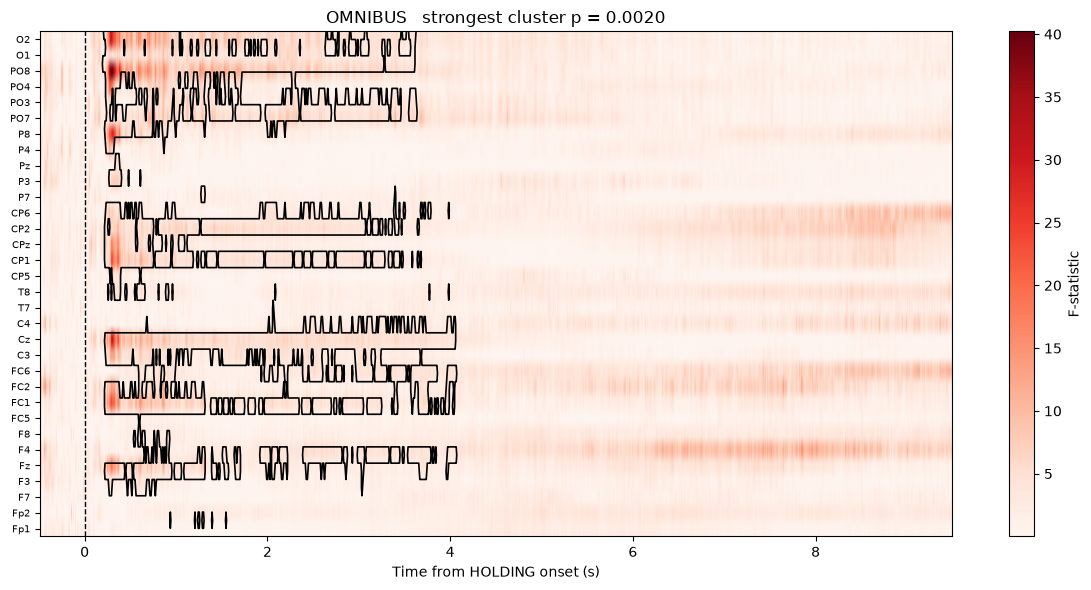

In [30]:
plot_cluster_map(T_obs_omni, clusters_omni, p_omni, "OMNIBUS")

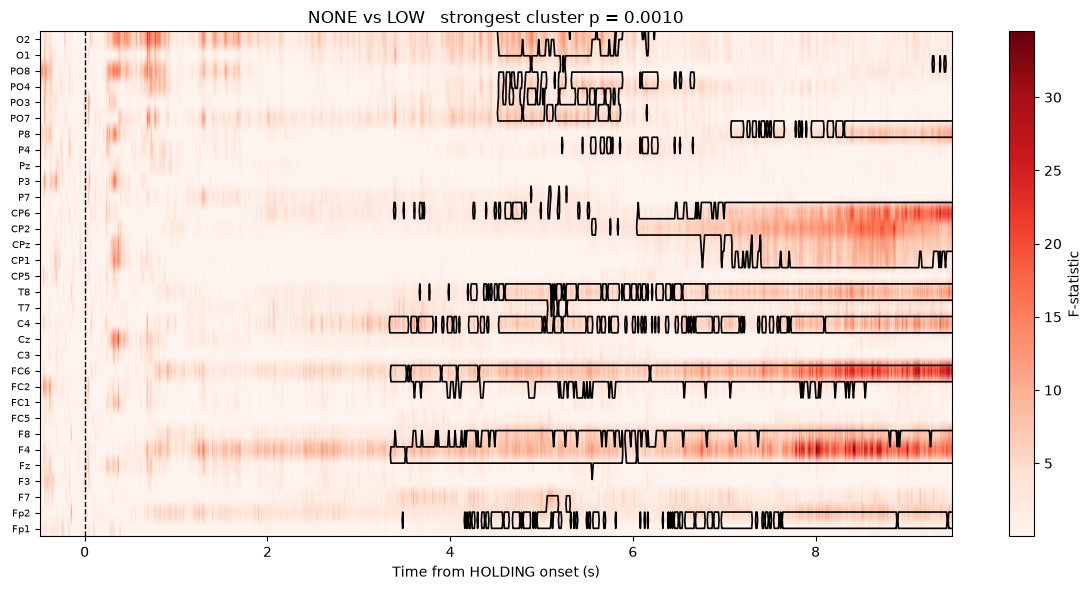

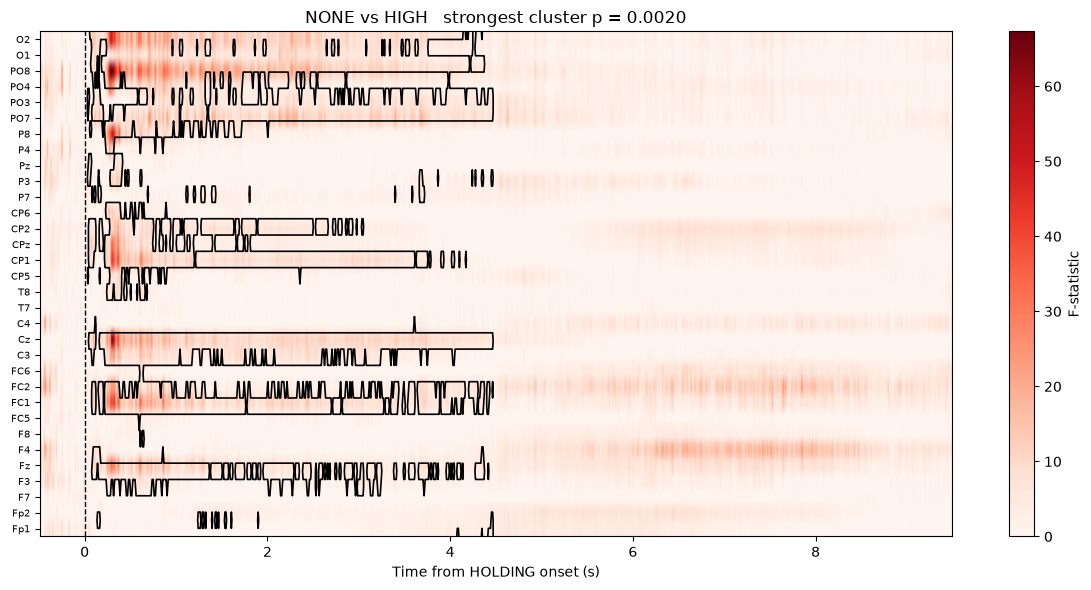

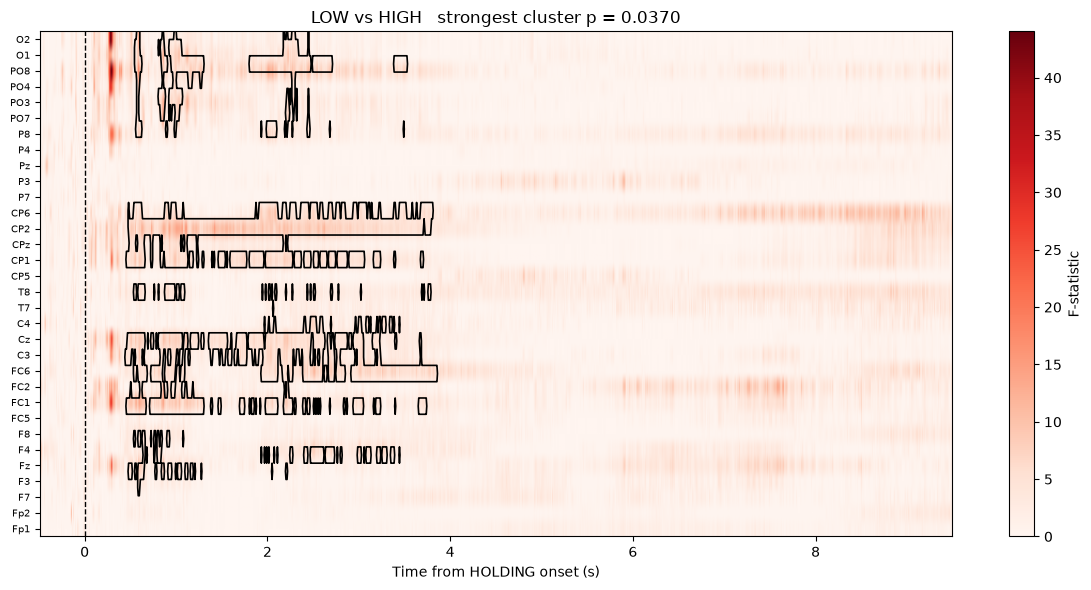

In [31]:
for a, b in pairs:
    plot_cluster_map(
        results[(a, b)]["T_obs"],
        results[(a, b)]["clusters"],
        results[(a, b)]["p_values"],
        f"{a.upper()} vs {b.upper()}",
    )

## **Topography of the cluster extension**

In [32]:
def plot_cluster_topo(clusters, p_values, label):
    if len(p_values) == 0:
        print(f"{label}: sin clusters")
        return

    best = int(np.argmin(p_values))
    mask = clusters[best]

    # Calculate the proportion of significant samples per channel
    coverage = mask.sum(axis=0) / mask.shape[0]

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    mne.viz.plot_topomap(
        coverage,
        epochs_clean.info,
        axes=ax,
        show=False,
        cmap="Reds",
        contours=0,
    )
    ax.set_title(f"{label}\np = {p_values[best]:.4f}", fontsize=10)
    plt.tight_layout()
    plt.show()

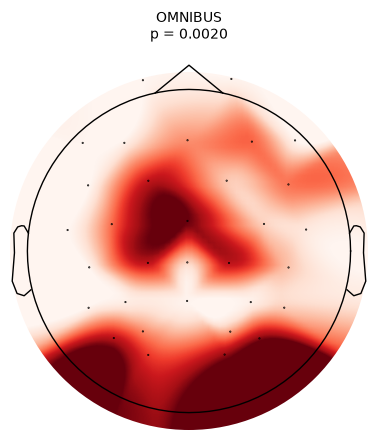

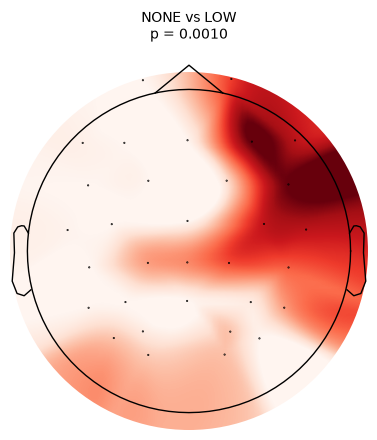

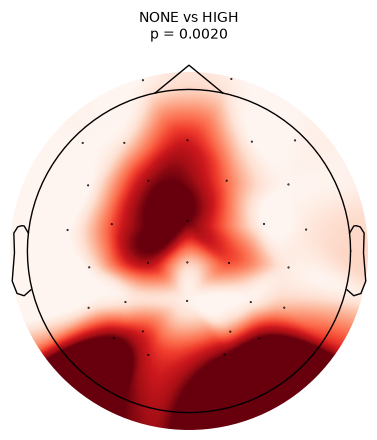

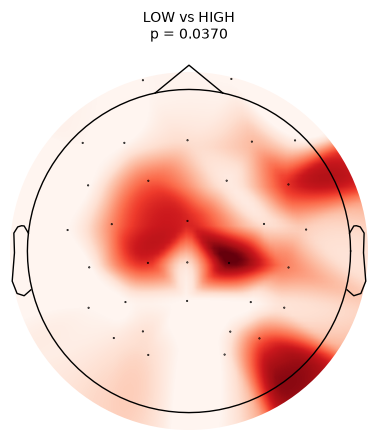

In [33]:
plot_cluster_topo(clusters_omni, p_omni, "OMNIBUS")

for a, b in pairs:
    plot_cluster_topo(
        results[(a, b)]["clusters"],
        results[(a, b)]["p_values"],
        f"{a.upper()} vs {b.upper()}",
    )

# **Control checks**

Two checks that decide whether the separation above can be reported. Both are listed as risks
in the interpretation notes, so they are run rather than assumed.

## **1. Is the effect an artifact of the baseline?**

The correction window runs from -0.5 to 0 s relative to the holding onset, which places it inside
the inflation ramp. The ramp length is tied to the condition (about 0.25 s for none, 3.7 s for low,
7.0 s for high), so the baseline is not neutral. The test is repeated with `baseline=None`. If the
cluster survives, the effect is not produced by the correction.

In [34]:
epochs_nobase_by_run = []

for run_name in RUNS:
    raw, phase_state, trial_state, target_state = load_run(run_name)
    events, trials, conditions = hold_events(phase_state, trial_state, target_state)

    bads = preprocess(raw)
    raw_clean, eog_indices, eog_proxy = run_ica(raw, bads)

    epochs = mne.Epochs(
        raw_clean,
        events,
        event_id = EVENT_ID,
        tmin = TMIN,
        tmax = TMAX,
        baseline = None,
        preload = True,
        decim = DECIM,
        proj = True,
    )
    epochs.metadata = pd.DataFrame({
        "run": [run_name] * len(trials),
        "trial": trials,
        "condition": conditions,
    })

    epochs_nobase_by_run.append(epochs)
    del raw, raw_clean

epochs_nobase = mne.concatenate_epochs(epochs_nobase_by_run)

ar_nb = AutoReject(random_state = SEED, n_jobs = 1, verbose = False)
epochs_nobase_clean, _ = ar_nb.fit_transform(epochs_nobase, return_log = True)

print(f"Kept {len(epochs_nobase_clean)} / {len(epochs_nobase)} epochs")

Kept 120 / 120 epochs


In [35]:
# How different was the pre-holding level across conditions? This is the confound itself.
b_window = (epochs_nobase_clean.times >= -0.5) & (epochs_nobase_clean.times <= 0.0)

for condition in ["none", "low", "high"]:
    data = epochs_nobase_clean[f"condition == '{condition}'"].get_data(picks = central_roi)
    level = data[:, :, b_window].mean(axis = 1).mean(axis = 1) * 1e6
    print(f"{condition:5s} pre-holding level: {level.mean():+.3f} uV  (sd {level.std():.3f})")

none  pre-holding level: -1.067 uV  (sd 3.053)
low   pre-holding level: -0.923 uV  (sd 4.285)
high  pre-holding level: +0.910 uV  (sd 4.197)


In [36]:
X_nb = {}
for condition in ["none", "low", "high"]:
    data = epochs_nobase_clean[f"condition == '{condition}'"].get_data(picks="eeg")
    X_nb[condition] = data.transpose(0, 2, 1)

T_nb, clusters_nb, p_nb = run_cluster_test(
    "OMNIBUS sin baseline",
    [X_nb["none"], X_nb["low"], X_nb["high"]],
)

T_nb2, clusters_nb2, p_nb2 = run_cluster_test(
    "NONE vs HIGH sin baseline",
    [X_nb["none"], X_nb["high"]],
    alpha = ALPHA_PAIR,
)

OMNIBUS sin baseline
clusters formados: 411   significativos (p < 0.05): 2
p minimo: 0.0040

* Cluster 1: p = 0.0040, 1050 nodes, t = [5.68, 9.19] s, 17 channels
    C4, CP1, CP2, CP5, CP6, CPz, Cz, FC1, FC2, P3, P4, P7, P8, PO3, PO4, PO7, T8
* Cluster 2: p = 0.0220, 747 nodes, t = [1.92, 4.46] s, 12 channels
    C3, C4, CP1, CP2, CPz, Cz, F3, FC1, FC2, FC5, FC6, T8
  Cluster 3: p = 0.1040, 318 nodes, t = [0.08, 0.74] s, 23 channels
    C4, CP1, CP2, CP6, CPz, F4, F7, F8, FC2, FC6, Fp2, O1, O2, P3, P4, P7, P8, PO3, PO4, PO7, PO8, T7, T8
  Cluster 4: p = 0.2190, 156 nodes, t = [-0.36, 0.07] s, 9 channels
    O1, O2, P3, P7, PO3, PO4, PO7, PO8, T7
  Cluster 5: p = 0.3180, 143 nodes, t = [-0.33, 0.07] s, 15 channels
    C3, C4, CP2, CP6, Cz, F3, F4, F7, F8, FC1, FC2, Fp2, Fz, P4, T7

NONE vs HIGH sin baseline
clusters formados: 334   significativos (p < 0.016666666666666666): 2
p minimo: 0.0070

* Cluster 1: p = 0.0070, 1169 nodes, t = [1.23, 4.48] s, 18 channels
    C3, C4, CP1, CP2, CP6

## **2. Is the effect muscular?**

In the high condition the arm is compressed with far more force than in none. A sustained difference
over temporal and frontal channels could be EMG rather than cortical activity. The 20 to 40 Hz RMS
is compared across conditions. If high shows clearly more power over T7 and T8, the cluster cannot be
attributed to nociceptive processing.

In [37]:
epochs_emg = epochs_clean.copy().filter(l_freq = 20.0, h_freq = 40.0, picks = "eeg")
emg_window = (epochs_emg.times >= 0.0) & (epochs_emg.times <= 9.5)

rows = []
for condition in ["none", "low", "high"]:
    data = epochs_emg[f"condition == '{condition}'"].get_data(picks = "eeg")
    row = {"condition": condition}
    for group_name, names in [("temporal", ["T7", "T8"]), ("central", ["Cz", "C3", "C4"])]:
        idx = []
        for name in names:
            if name in epochs_emg.ch_names:
                idx.append(epochs_emg.ch_names.index(name))
        segment = data[:, idx][:, :, emg_window]
        row[group_name + "_rms_uV"] = np.sqrt((segment ** 2).mean(axis = 2)).mean() * 1e6
    rows.append(row)

pd.DataFrame(rows)

,condition,temporal_rms_uV,central_rms_uV
0,none,2.570266,1.200072
1,low,2.434254,1.183707
2,high,2.291628,1.135805


# **Evoked Related Potential (ERP) per condition**

In [38]:
# Select all epochs where the condition is 'none' and compute their average (Evoked response)
none_evoked = epochs_clean["condition == 'none'"].average()

# Select all epochs where the condition is 'low' and compute their average (Evoked response)
low_evoked = epochs_clean["condition == 'low'"].average()

# Select all epochs where the condition is 'high' and compute their average (Evoked response)
high_evoked = epochs_clean["condition == 'high'"].average()

# Print the number of epochs used for each Evoked response
print("condition")
print("none \t", len(epochs_clean["condition == 'none'"]))
print("low \t", len(epochs_clean["condition == 'low'"]))
print("high \t", len(epochs_clean["condition == 'high'"]))

condition
none 	 40
low 	 40
high 	 40


## **None Pain ERP**

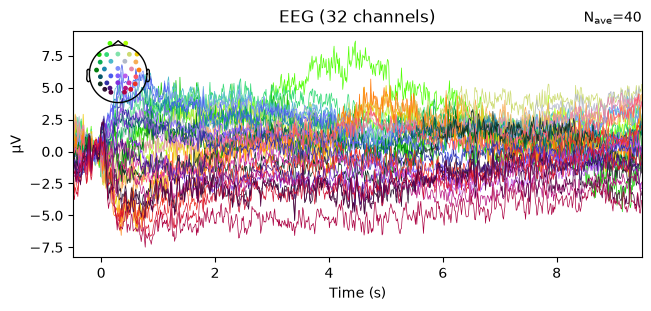

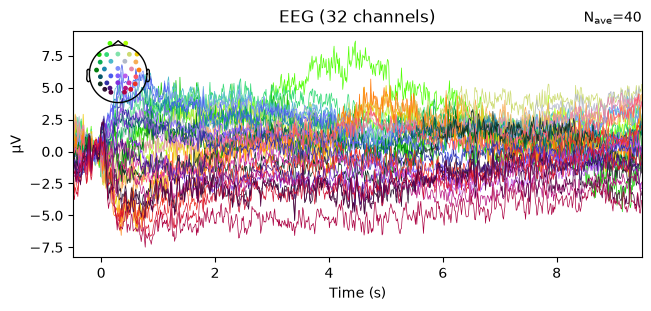

In [39]:
none_evoked.plot(spatial_colors=True)

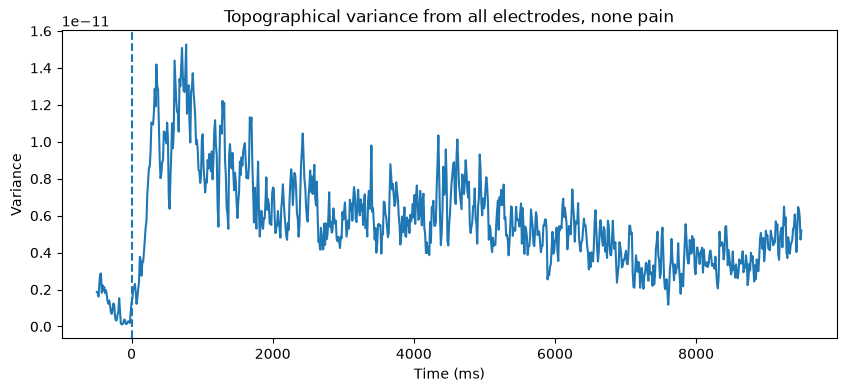

In [40]:
# ERP data: channels x timepoints
data = none_evoked.data

# Variance across all electrodes at each timepoint
topographical_variance = np.var(data, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    none_evoked.times * 1000,
    topographical_variance
)

ax.set_title("Topographical variance from all electrodes, none pain")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Variance")

ax.axvline(0, linestyle="--")

plt.show()

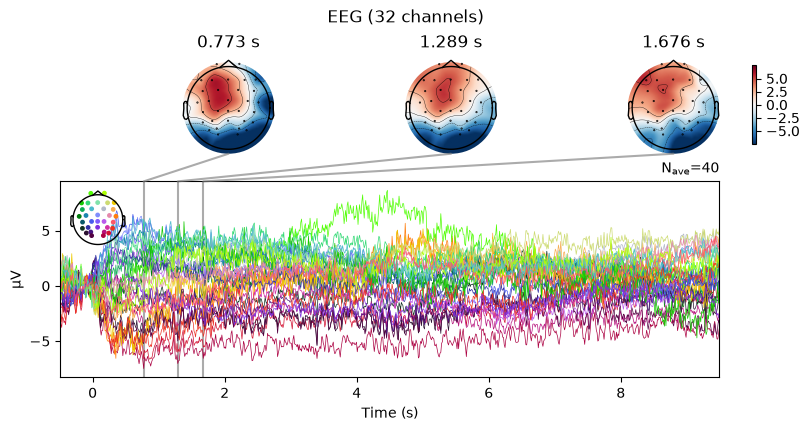

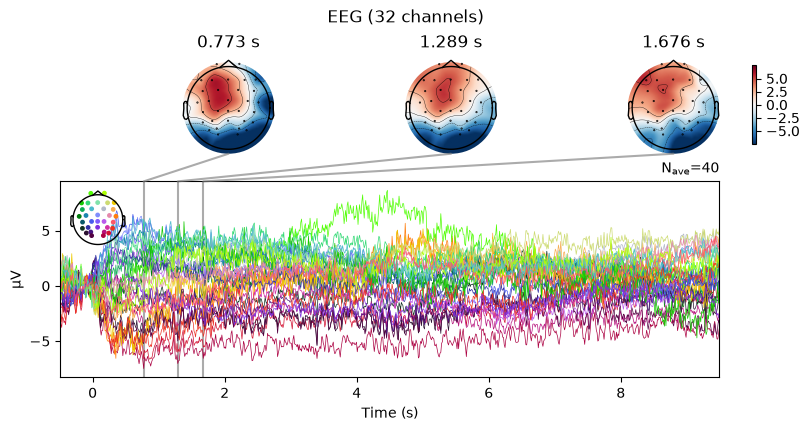

In [41]:
none_evoked.plot_joint()

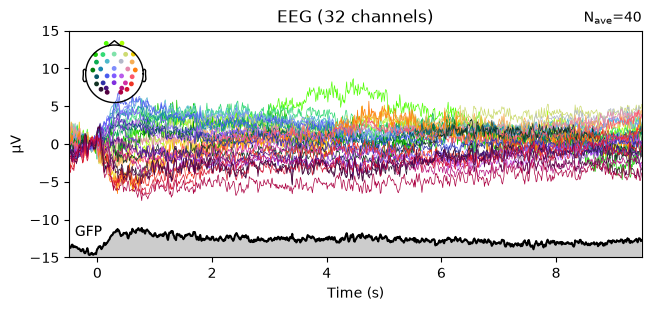

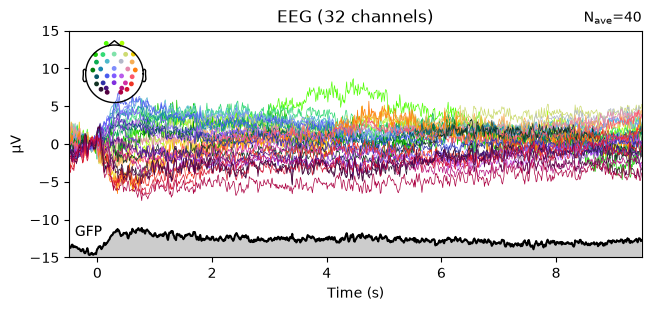

In [42]:
none_evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-15, 15]))

# **Low Pain ERP**

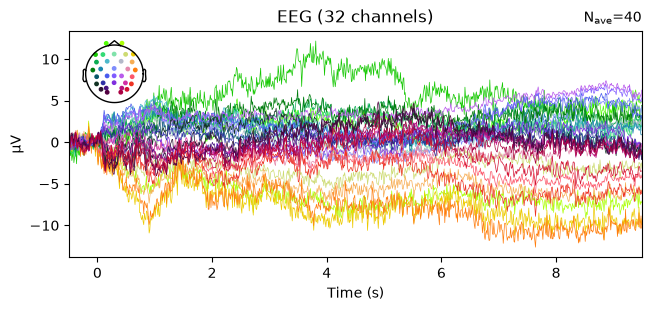

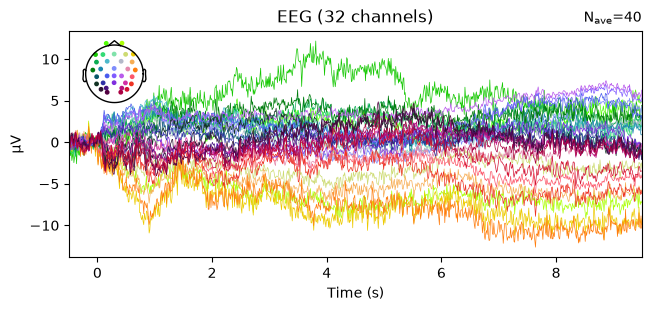

In [43]:
low_evoked.plot(spatial_colors=True)

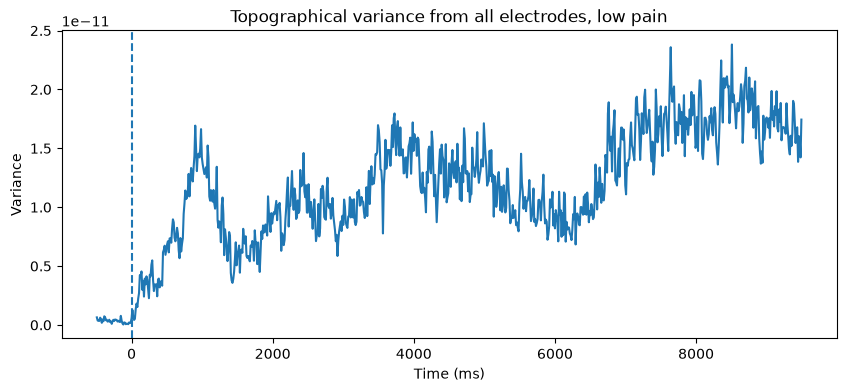

In [44]:
# ERP data: channels x timepoints
data = low_evoked.data

# Variance across all electrodes at each timepoint
topographical_variance = np.var(data, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    low_evoked.times * 1000,
    topographical_variance
)

ax.set_title("Topographical variance from all electrodes, low pain")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Variance")

ax.axvline(0, linestyle="--")

plt.show()

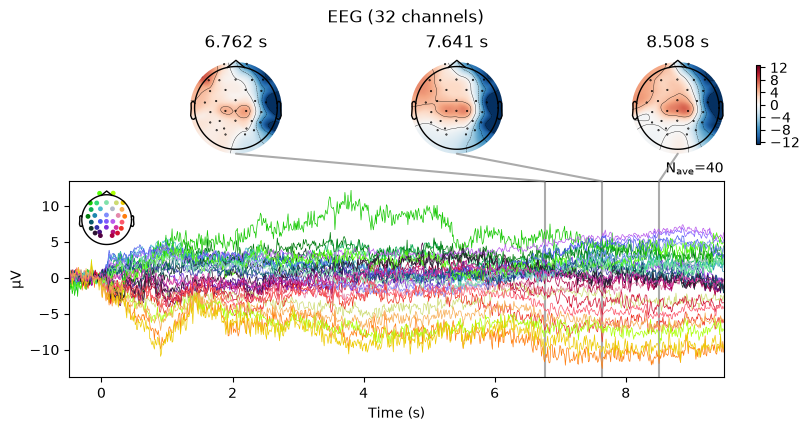

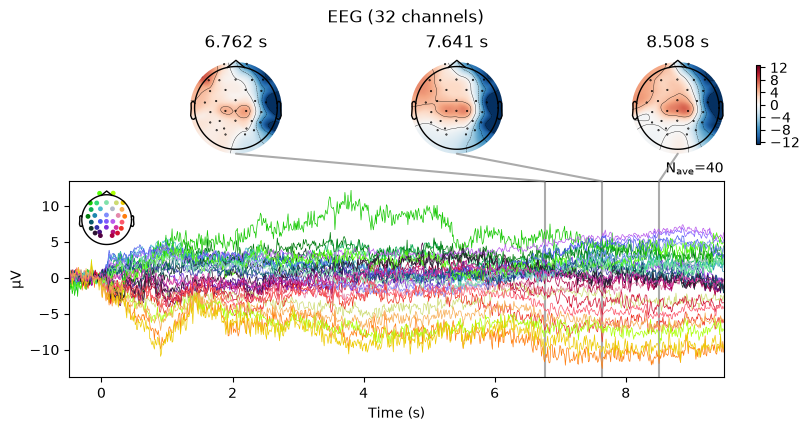

In [45]:
low_evoked.plot_joint()

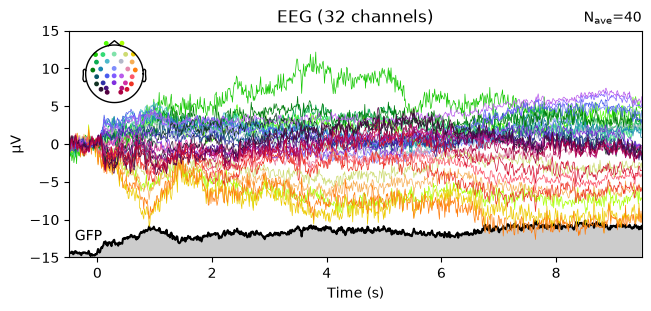

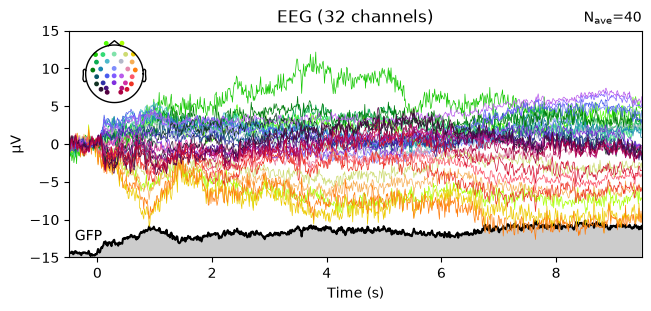

In [46]:
low_evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-15, 15]))

## **High Pain ERP**

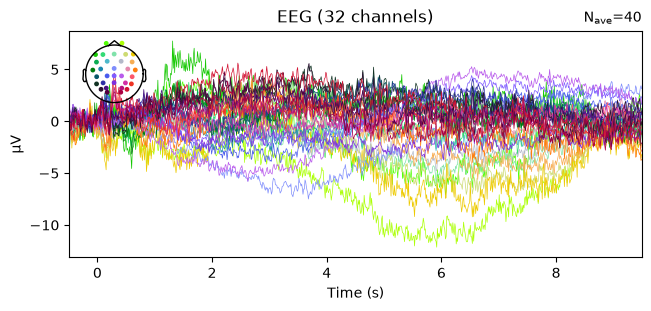

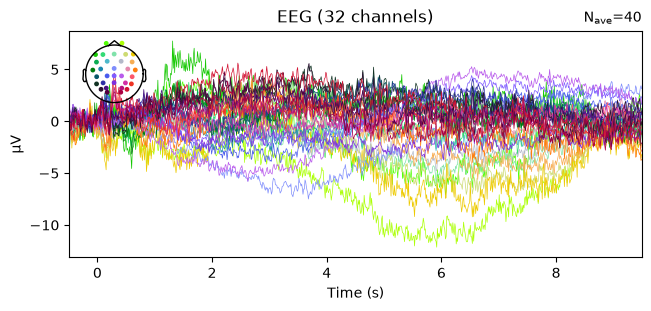

In [47]:
high_evoked.plot(spatial_colors=True)

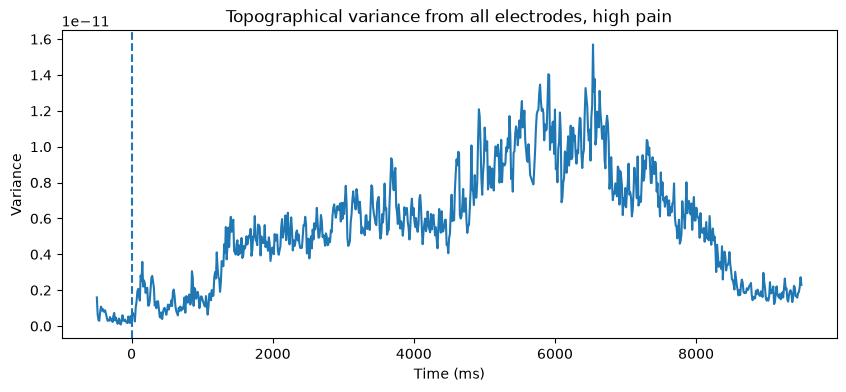

In [48]:
# ERP data: channels x timepoints
data = high_evoked.data

# Variance across all electrodes at each timepoint
topographical_variance = np.var(data, axis=0)

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    high_evoked.times * 1000,
    topographical_variance
)

ax.set_title("Topographical variance from all electrodes, high pain")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Variance")

ax.axvline(0, linestyle="--")

plt.show()

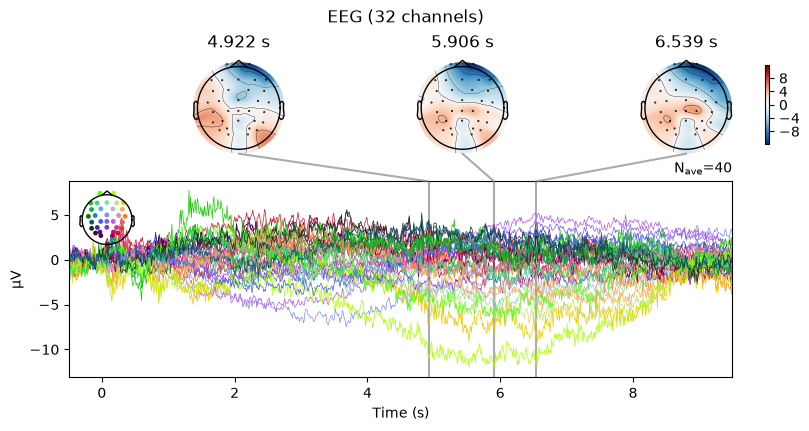

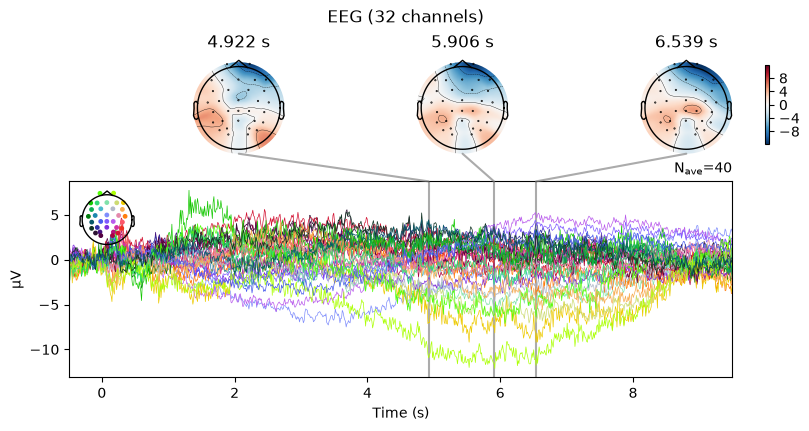

In [49]:
high_evoked.plot_joint()

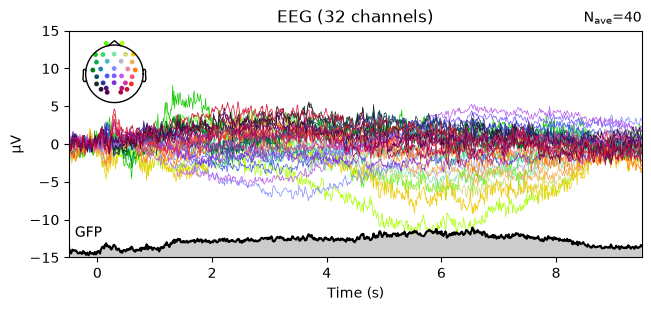

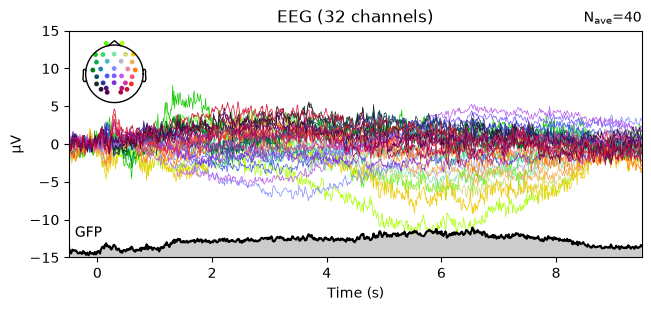

In [50]:
high_evoked.plot(gfp=True, spatial_colors=True, ylim=dict(eeg=[-15, 15]))

# **Time-Frquency analysis**

Tonic pain is usually reported as a sustained suppression of alpha and beta rather than a deflection
in the averaged amplitude, so this section asks the question in the spectral domain. Two views:
a Welch PSD collapsed over the whole holding window, and a Morlet time-frequency decomposition that
keeps the time axis.

Same conditions, same ROI, same cluster machinery as the amplitude analysis.

## **Settings**

In [54]:
import matplotlib.pyplot as plt

import mne
from mne import io
from mne.datasets import sample
from mne.minimum_norm import compute_source_psd, read_inverse_operator

print(__doc__)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
¿Puedo bajar de 256 Hz a una frecuencia menor para hacer los cálculos más rápidos?


In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

CENTRAL_ROI = ["Cz", "C3", "C4", "CPz", "CP1", "CP2", "FC1", "FC2"]

# Verifica que los nombres coincidan exactamente con los de tu montaje
# (mayúsculas/minúsculas importan en MNE, ej. "Cz" vs "CZ")
present = [ch for ch in CENTRAL_ROI if ch in epochs_clean.info["ch_names"]]
missing = [ch for ch in CENTRAL_ROI if ch not in epochs_clean.info["ch_names"]]
if missing:
    print("Canales no encontrados:", missing)

# PSD solo de esos canales
spectrum = epochs_clean.compute_psd(
    method="welch",
    picks=present,
    fmin=0.5, fmax=60,
    n_fft=int(2 * epochs_clean.info["sfreq"]),  # ventanas de 2 s
)
psd = spectrum.get_data()          # (n_canales, n_freqs), en V²/Hz
freqs = spectrum.freqs

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(12, 7))

colors = cm.plasma(np.linspace(0, 1, len(present)))
for ch, color, row in zip(present, colors, psd):
    ax.plot(freqs, row, label=ch, color=color, linewidth=1.2)

ax.set_yscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power/Frequency (V²/Hz)")
ax.set_title("Power Spectral Density (PSD) — ROI Central")

# Bandas de frecuencia
ax.axvspan(4, 8, color="lightblue", alpha=0.3, label="Theta Band (4-8 Hz)")
ax.axvspan(8, 12, color="lightgreen", alpha=0.3, label="Alpha Band (8-12 Hz)")
ax.axvspan(13, 30, color="lightpink", alpha=0.3, label="Beta Band (13-30 Hz)")

# Ruido de línea (usa 60 Hz si estás en México/EUA, 50 Hz si es Europa)
ax.axvline(60, color="red", linestyle="--", linewidth=1.5, label="Power Line Noise (60 Hz)")

ax.set_xlim(0, freqs.max())
ax.legend(loc="upper right", fontsize=8, ncol=1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: Requested fmax (60 Hz) must not exceed ½ the sampling frequency of the data (42.666666666666664 Hz).

In [69]:
print(
    epochs_clean.metadata.groupby(["run", "condition"])
    .size()
    .unstack(fill_value=0)
)

condition    high  low  none
run                         
P001S001R02    10   10    10
P001S001R03    10   10    10
P001S001R04    10   10    10
P001S001R05    10   10    10


In [70]:
epochs_clean.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, C3, Cz, C4, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.1 Hz
 lowpass: 40.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: Average EEG reference: on
 sfreq: 85.3 Hz
>